In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

folder_path = Path(r"C:\Users\user\Desktop\Gibeom\1. HI Lab\0. Projects\0. On going\1-2. [Lead] Triboresistive sensor\1. [Lead] DC TRS\1. 실험자료\260809_series connected\csv파일")

save_summary = False
output_filename = "Average_summary.csv"


Found 10 CSV files.
Processed: I_1cell.csv | Average = 0.145792
Processed: I_2cell_series.csv | Average = 0.135997
Processed: I_3cell_series.csv | Average = 0.089989
Processed: I_4cell_series.csv | Average = 0.079192
Processed: I_ground.csv | Average = -0.001232
Processed: V_1cell.csv | Average = 0.449066
Processed: V_2cell.csv | Average = 0.594857
Processed: V_3cell.csv | Average = 1.259007
Processed: V_4cell.csv | Average = 1.417367
Processed: V_ground.csv | Average = -0.068237
----------------------------------------


,File Name,Average Value,Data Count,Max Value,Min Value
0,I_1cell.csv,0.145792,10000,0.146984,0.144734
1,I_2cell_series.csv,0.135997,10000,0.137672,0.134344
2,I_3cell_series.csv,0.089989,10000,0.090703,0.089234
3,I_4cell_series.csv,0.079192,10000,0.080234,0.078109
4,I_ground.csv,-0.001232,10000,-0.000858,-0.001669
5,V_1cell.csv,0.449066,10000,0.454844,0.441484
6,V_2cell.csv,0.594857,10000,0.599922,0.589141
7,V_3cell.csv,1.259007,10000,1.275630,1.241480
8,V_4cell.csv,1.417367,10000,1.430470,1.406800
9,V_ground.csv,-0.068237,10000,-0.063703,-0.072203


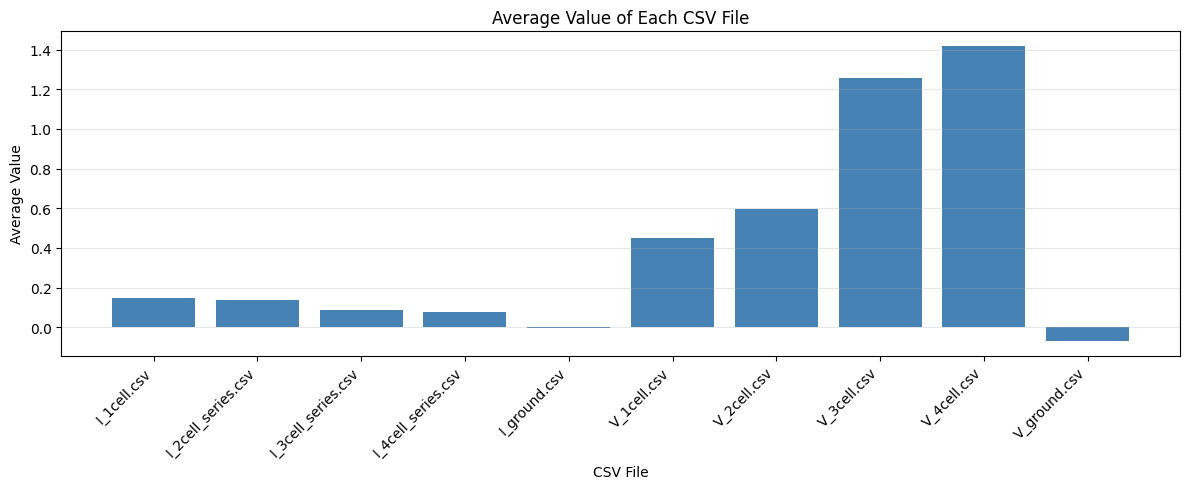

In [4]:
csv_files = sorted(folder_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files were found in: {folder_path}")

results = []

print(f"Found {len(csv_files)} CSV files.")

for csv_file in csv_files:
    df = pd.read_csv(csv_file, header=None, usecols=[0, 1])
    df.columns = ["Time", "Value"]

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    df = df.dropna(subset=["Time", "Value"]).reset_index(drop=True)

    if df.empty:
        print(f"Skipped {csv_file.name}: no valid numeric data.")
        continue

    average_value = df["Value"].mean()
    value_count = len(df)

    results.append({
        "File Name": csv_file.name,
        "Average Value": average_value,
        "Data Count": value_count,
        "Max Value": df["Value"].max(),
        "Min Value": df["Value"].min()
    })

    print(f"Processed: {csv_file.name} | Average = {average_value:.6f}")

summary_df = pd.DataFrame(results)

if summary_df.empty:
    raise ValueError("No valid CSV data was processed.")

summary_df = summary_df.sort_values("File Name").reset_index(drop=True)
summary_df = summary_df.round({
    "Average Value": 6,
    "Max Value": 6,
    "Min Value": 6
})

print("-" * 40)
display(summary_df)

if save_summary:
    output_path = folder_path / output_filename
    summary_df.to_csv(output_path, index=False, encoding="utf-8-sig")
    print(f"Summary saved to: {output_path}")


plt.figure(figsize=(12, 5))
plt.bar(summary_df["File Name"], summary_df["Average Value"], color="steelblue")
plt.xlabel("CSV File")
plt.ylabel("Average Value")
plt.title("Average Value of Each CSV File")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
